In [4]:
# ENVIRONMENT SETUP
# Run this cell once if packages are not yet installed
import subprocess, sys

required = [
    "pyarrow",       # read .parquet files
    "statsmodels",   # OLS regression
    "seaborn",       # heatmap
    "scikit-learn",  # random forest
]
for pkg in required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

In [5]:
# IMPORTS
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey


# What Is Actually Making Sofia's Air Dirty?
## A Multi-Predictor Regression Study of PM10 in Sofia, Bulgaria

---

Sofia consistently ranks among the most polluted EU capitals. Every winter, a thick grey smog settles over the city — a visible sign of dangerously high concentrations of **particulate matter (PM)**. The most regulated size fraction is **PM10** — particles under 10 micrometres in diameter — for which the EU sets a legal annual average limit of 40 µg/m³. Sofia routinely exceeds it.

The usual suspects are well known: wood-burning stoves, old diesel cars, industrial activity. But Bulgaria's electricity grid has also changed dramatically — lignite (brown coal) generation collapsed 59% in 2024, with CO₂-free sources now comprising 66% of the power mix (Ember Monthly Electricity Data, 2023).

So here is the question nobody has cleanly answered: **does grid-level decarbonization actually show up in Sofia's air quality (AQ), or is the signal completely buried under heating season and weather?**

To answer it, we can't just plot energy mix against pollution and call it correlation. We have to control for the things that dominate — temperature, wind, the heating season — and then look at what's left. That remainder, if anything, belongs to the grid.

We will:
1. Collect and merge three independent data sources: EEA station-level PM10 measurements, Ember monthly electricity generation data, and ERA5 meteorological reanalysis via Open-Meteo
2. Explore the data and establish the seasonal and meteorological structure of Sofia's PM10 exceedances
3. Build a multiple linear regression model with heating season, wind speed, temperature, and lignite generation share as predictors
4. Quantify the partial effect of the energy mix after controlling for the dominant confounders
5. Cross-validate findings using a Random Forest model and compare feature importances
6. Interpret the result honestly — including if the grid signal doesn't survive the controls

---
## Section 1 — Problem Formulation

### 1.1 The Air Quality Problem

Air pollution in Sofia is fundamentally a **source attribution problem**. PM10 in the air above the city at any given moment is the sum of contributions from multiple independent sources: domestic solid fuel heating, road traffic, industry, and — indirectly — the national electricity grid through its fossil fuel plants.

The challenge is that these sources are correlated with each other and with external factors. Cold days mean more heating *and* more atmospheric stability (reduced vertical mixing, so pollutants accumulate). Winter means both heating season *and* low wind speeds in Sofia's valley basin. A naive regression of PM10 on energy mix would absorb all of these.

The central question is:

> **To what extent does the electricity generation mix influence PM10 levels in Sofia, once we control for heating season and meteorological conditions?**

This problem can be approached using regression analysis to study the relationship between Bulgaria’s energy mix and PM10 levels in Sofia. Since controlled experiments are not feasible, we rely on observational data and attempt to account for major confounding factors such as weather conditions and seasonality. The goal is to assess whether the energy mix variable retains a statistically significant association with PM10 concentrations after controlling for these factors.

However, due to the observational nature of the data and the use of proxy variables, the results should be interpreted as associations rather than causal effects.

### 1.2 Why Multiple Regression?

Multiple linear regression (MLR) is the right starting tool here because it directly answers a question of the form: *what is the effect of variable X on outcome Y, holding variables Z₁, Z₂, ... constant?* The coefficient on lignite share is exactly that partial effect — the change in PM10 associated with a one-unit change in lignite generation share, after removing the contribution of temperature, wind, and season.

This is not the only approach. The tradeoffs between methods are:

| Method | Pros | Cons |
|---|---|---|
| Multiple Linear Regression | Interpretable coefficients, p-values, partial effects | Assumes linearity, sensitive to outliers |
| Random Forest | Captures non-linear interactions, robust | No direct partial effects, black box |
| ARIMA / time series | Handles autocorrelation explicitly | Doesn't naturally incorporate exogenous variables |
| Causal inference (IV, DiD) | Strongest causal claims | Requires valid instruments, complex setup |

We use MLR as the primary method and Random Forest as a flexible non-linear benchmark.

### 1.3 Hypotheses

**H₁ (Primary):** Heating season and meteorological variables will explain the majority of variance in monthly PM10 concentrations, with lignite generation share retaining a small but statistically significant positive partial effect after controlling for these factors.

**H₂ (Alternative):** The partial effect of lignite generation on PM10 is not statistically significant once heating season and meteorology are controlled for — implying grid-level decarbonization has not produced a detectable signal in urban air quality at the monthly timescale.

**H₀ (Null):** None of the predictor variables has a significant linear relationship with PM10 concentrations in Sofia.

### 1.4 Assumptions & Constraints

Our model makes the following explicit assumptions:
- ERA5 reanalysis data from Open-Meteo is a valid proxy for local meteorological conditions in Sofia (~9 km spatial resolution)
- National-level generation data from Ember is a valid proxy for grid dispatch conditions affecting Sofia — Bulgaria operates as a single bidding zone with no sub-regional breakdown
- Domestic heating intensity is proxied by a binary heating season variable (October–March) and heating degree days derived from temperature — not directly measured
- The relationship between predictors and PM10 is approximately linear at monthly aggregation

**Known limitations:**
- The model cannot directly measure domestic wood/coal burning — the largest single PM10 source in Sofia. This is the primary structural limitation.
- Traffic counts are not included, so traffic-related variation is not directly measured in the model.
- Causal claims cannot be made from observational regression alone. This is an associational study with controlled confounders.

---
## Section 2 — The Mathematics of Regression with Confounders

### 2.1 Multiple Linear Regression

The core model is:

$$\text{PM10}_t = \beta_0 + \beta_1 \cdot \text{HeatingDays}_t + \beta_2 \cdot \text{WindSpeed}_t + \beta_3 \cdot \text{Temperature}_t + \beta_4 \cdot \text{LigniteShare}_t + \beta_5 \cdot \text{Month}_t + \varepsilon_t$$

Where:
- $\text{PM10}_t$ is the monthly average PM10 concentration at Sofia monitoring stations (µg/m³)
- $\text{HeatingDays}_t$ is the total heating degree days in month t (sum over daily values) — a continuous proxy for heating demand
- $\text{WindSpeed}_t$ is the monthly average of daily maximum 10m wind speed (m/s) — used as a proxy for atmospheric dispersion conditions
  (Although this measure does not directly represent average wind conditions, higher maximum wind speeds are associated with increased atmospheric mixing and pollutant dispersion.)
- $\text{Temperature}_t$ is the mean monthly temperature (°C) — controls for atmospheric stability and heating demand
- $\text{LigniteShare}_t$ represents lignite-based electricity generation as a fraction of total generation (0–1), used as a proxy for coal-related emissions at the national level.
- $\text{Month}_t$ captures residual seasonality not explained by temperature and heating demand variables
- $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ represents the error term, assumed to have mean zero; normality and independence are not strictly guaranteed and are assessed empirically.

The coefficient of interest is $\beta_4$. Its sign, magnitude, and statistical significance provide evidence about the association between coal share and PM10.

### 2.2 Ordinary Least Squares Estimation

In matrix form, the model is:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

where $\mathbf{y} \in \mathbb{R}^n$ is the vector of PM10 observations, $\mathbf{X} \in \mathbb{R}^{n \times p}$ is the design matrix of predictors (with a column of ones for the intercept), and $\boldsymbol{\beta} \in \mathbb{R}^p$ is the vector of coefficients.

The OLS estimator minimizes the sum of squared residuals:

$$\hat{\boldsymbol{\beta}} = \underset{\boldsymbol{\beta}}{\arg\min} \left\| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \right\|^2$$

The closed-form solution is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

This requires $\mathbf{X}^\top \mathbf{X}$ to be invertible — which fails under perfect multicollinearity. We check for this using the **Variance Inflation Factor (VIF)**.

### 2.3 Assessing Coefficient Significance

Under the Gauss-Markov assumptions, the OLS estimator is BLUE (Best Linear Unbiased Estimator).
However, in this setting, these assumptions may not fully hold — particularly the independence of errors — due to the time-series nature of the data. The standard error of each coefficient is:

$$\text{SE}(\hat{\beta}_j) = \sqrt{s^2 \left[(\mathbf{X}^\top \mathbf{X})^{-1}\right]_{jj}}$$

where $s^2 = \frac{\|\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}\|^2}{n - p}$ is the residual variance estimate.

The t-statistic for testing $H_0: \beta_j = 0$ is:

$$t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \sim t_{n-p}$$

We reject $H_0$ at the $\alpha = 0.05$ level if $|t_j| > t_{n-p, 0.025}$, equivalently if $p\text{-value} < 0.05$.

### 2.4 Model Fit: R² and Adjusted R²

The coefficient of determination $R^2$ measures the proportion of variance in PM10 explained by the model:

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum_t (y_t - \hat{y}_t)^2}{\sum_t (y_t - \bar{y})^2}$$

Since $R^2$ increases mechanically with additional predictors, we also report the adjusted $R^2$, which penalises model complexity:

$$\bar{R}^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

### 2.5 Variance Inflation Factor (Multicollinearity Check)

Temperature and heating degree days are correlated by construction. The VIF for predictor $j$ measures how much its variance is inflated by collinearity with the other predictors:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the $R^2$ from regressing predictor $j$ on all other predictors. A VIF above 10 is typically considered problematic and may warrant dropping or combining collinear features.

---
## Section 3 — Data Collection

### 3.1 Sources

| # | Source | What it provides | Access |
|---|---|---|---|
| 1 | EEA Air Quality e-Reporting Database | Daily PM10 at Sofia stations, 2015–2023 | `data/eea/*.parquet` |
| 2 | Ember Monthly Electricity Data | Monthly generation by fuel type for Bulgaria, 2015–2023 | `data/monthly_full_release_long_format.csv` |
| 3 | Open-Meteo Historical Weather API | Daily ERA5 temperature, wind speed, precipitation at Sofia (42.70°N, 23.32°E) | `data/sofia_weather_era5.csv` |


The EEA database is the authoritative, validated source for ambient air quality in Europe — the same data used in EU compliance assessments. Ember aggregates Eurostat and ENTSO-E generation data into a clean, citable monthly time series, removing the need for ENTSO-E API registration. Open-Meteo provides ERA5 reanalysis meteorology, which is the global standard for long-period weather reconstruction — consistent, gap-free, and extending back to 1940.

**Data source references:**
- EEA Air Quality e-Reporting: https://eeadmz1-downloads-webapp.azurewebsites.net/
- Ember Monthly Electricity Data: https://ember-energy.org/data/monthly-electricity-data/
- Open-Meteo ERA5: https://open-meteo.com/en/docs/historical-weather-api — Hersbach et al. (2023). ERA5 hourly data on single levels from 1940 to present. ECMWF. https://doi.org/10.24381/cds.adbb2d47

All files are pre-downloaded and committed to this repository. No API calls or downloads are needed to run the notebook.

In [7]:
# ── LOAD PM10 ─────────────────────────────────────────────────────────────────
# Source: EEA Air Quality e-Reporting Database (Verified E1a, 2015–2024)
# Format: Parquet files, one per Sofia monitoring station
# Columns used: Start (date), Value (PM10 µg/m³), AggType ('day'), Validity (1=valid)
# Station codes: BG0024A, BG0040A, BG0050A, BG0052A, BG0070A, BG0073A, BG0079A

parquet_files = glob.glob("data/E1a/*.parquet")
print(f"Found {len(parquet_files)} EEA station files")

pm10_raw = pd.concat(
    [pd.read_parquet(f) for f in parquet_files],
    ignore_index=True
)

print(f"Total rows: {len(pm10_raw)}")
print(f"Columns: {pm10_raw.columns.tolist()}")
print(f"AggType values: {pm10_raw['AggType'].unique()}")
print(f"Validity values: {pm10_raw['Validity'].unique()}")
print(f"Date range: {pm10_raw['Start'].min()} to {pm10_raw['Start'].max()}")
pm10_raw.head(10)

Found 7 EEA station files
Total rows: 23758
Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit', 'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture', 'FkObservationLog']
AggType values: ['day']
Validity values: [ 1 -1]
Date range: 2015-01-01 00:00:00 to 2024-12-30 00:00:00


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog
0,BG/SPO-BG0024A_00005_100,5,2015-01-01,2015-01-02,77.300000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
1,BG/SPO-BG0024A_00005_100,5,2015-01-02,2015-01-03,91.200000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
2,BG/SPO-BG0024A_00005_100,5,2015-01-03,2015-01-04,47.600000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
3,BG/SPO-BG0024A_00005_100,5,2015-01-04,2015-01-05,29.400000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
4,BG/SPO-BG0024A_00005_100,5,2015-01-05,2015-01-06,31.300000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
5,BG/SPO-BG0024A_00005_100,5,2015-01-06,2015-01-07,30.600000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
6,BG/SPO-BG0024A_00005_100,5,2015-01-07,2015-01-08,89.300000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
7,BG/SPO-BG0024A_00005_100,5,2015-01-08,2015-01-09,107.400000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
8,BG/SPO-BG0024A_00005_100,5,2015-01-09,2015-01-10,70.600000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff
9,BG/SPO-BG0024A_00005_100,5,2015-01-10,2015-01-11,36.800000000000000000,ug.m-3,day,1,1,2017-09-01 10:23:27,None,77bf48fd-22c8-4a1e-8ee4-42fabe53dcff


In [8]:
# ── CLEAN PM10 ────────────────────────────────────────────────────────────────
# Keep only: daily aggregation, valid readings (Validity == 1), plausible range

pm10 = pm10_raw.copy()
pm10['date']  = pd.to_datetime(pm10['Start']).dt.normalize()
pm10['value'] = pd.to_numeric(pm10['Value'], errors='coerce')

pm10 = pm10[
    (pm10['AggType']   == 'day') &
    (pm10['Validity']  == 1)     &
    (pm10['value']     >= 0)     &
    (pm10['value']     < 500)      # remove obvious sensor errors
]

# Daily mean across all 7 stations
pm10_daily = (
    pm10.groupby('date')['value']
    .mean()
    .reset_index()
    .rename(columns={'value': 'pm10'})
)

# Monthly aggregation — require at least 15 valid days to avoid noisy months
pm10_daily['month'] = pm10_daily['date'].dt.to_period('M')
pm10_monthly = (
    pm10_daily.groupby('month')['pm10']
    .agg(pm10_mean='mean', n_days='count')
    .reset_index()
)
pm10_monthly = pm10_monthly[pm10_monthly['n_days'] >= 15]

print(f"Monthly PM10 rows: {len(pm10_monthly)}")
print(f"Date range: {pm10_monthly['month'].min()} to {pm10_monthly['month'].max()}")
print(f"Mean PM10: {pm10_monthly['pm10_mean'].mean():.1f} µg/m³")
print(f"Months above EU 40 µg/m³ limit: {(pm10_monthly['pm10_mean'] > 40).sum()} / {len(pm10_monthly)}")
pm10_monthly.head()

Monthly PM10 rows: 120
Date range: 2015-01 to 2024-12
Mean PM10: 29.2 µg/m³
Months above EU 40 µg/m³ limit: 14 / 120


,month,pm10_mean,n_days
0,2015-01,65.866720,31
1,2015-02,41.285000,28
2,2015-03,29.707258,31
3,2015-04,23.923611,30
4,2015-05,25.282785,31


In [9]:
# ── LOAD & CLEAN EMBER ────────────────────────────────────────────────────────
# Source: Ember Monthly Electricity Data (CC BY 4.0)
# File: monthly_full_release_long_format.csv
# Columns used: Area, Date, Category, Variable, Unit, Value
# We extract: Electricity generation (TWh) for Bulgaria, 2015–2024
# Note: Ember reports 'Coal' as a combined variable (includes lignite).
#       Lignite is not broken out separately at monthly national level.

ember_raw = pd.read_csv("data/monthly_full_release_long_format.csv")

# Filter to Bulgaria, generation only, TWh unit
ember = ember_raw[
    (ember_raw['Area']     == 'Bulgaria') &
    (ember_raw['Category'] == 'Electricity generation') &
    (ember_raw['Unit']     == 'TWh')
].copy()

ember['month'] = pd.to_datetime(ember['Date']).dt.to_period('M')

# Pivot: one row per month, one column per fuel type
gen = ember.pivot_table(
    index='month', columns='Variable', values='Value', aggfunc='sum'
).reset_index()

# Compute shares from Total Generation
gen['coal_share']       = gen['Coal']    / gen['Total Generation']
gen['nuclear_share']    = gen['Nuclear'] / gen['Total Generation']
gen['renewables_share'] = (
    gen.get('Wind', pd.Series(0, index=gen.index)) +
    gen.get('Solar', pd.Series(0, index=gen.index)) +
    gen.get('Hydro', pd.Series(0, index=gen.index))
) / gen['Total Generation']

# Restrict to 2015–2024 to match PM10 and weather
gen = gen[
    (gen['month'] >= '2015-01') &
    (gen['month'] <= '2024-12')
]

gen_monthly = gen[['month', 'coal_share', 'nuclear_share', 'renewables_share', 'Total Generation']]

print(f"Ember monthly rows: {len(gen_monthly)}")
print(f"Date range: {gen_monthly['month'].min()} to {gen_monthly['month'].max()}")
print(f"Avg coal share: {gen_monthly['coal_share'].mean():.2%}")
print(f"Avg nuclear share: {gen_monthly['nuclear_share'].mean():.2%}")
gen_monthly.head()

Ember monthly rows: 120
Date range: 2015-01 to 2024-12
Avg coal share: 42.10%
Avg nuclear share: 36.79%


Variable,month,coal_share,nuclear_share,renewables_share,Total Generation
0,2015-01,0.539095,0.312757,0.146091,4.86
1,2015-02,0.489260,0.329356,0.178998,4.19
2,2015-03,0.428241,0.356481,0.210648,4.32
3,2015-04,0.510471,0.253927,0.232984,3.82
4,2015-05,0.447130,0.311178,0.235650,3.31


In [10]:
# ── LOAD & CLEAN WEATHER ──────────────────────────────────────────────────────
# Source: Open-Meteo Historical Weather API — ERA5 reanalysis
# File: sofia_weather_era5.csv
# Columns: time, temperature_2m_mean (°C), wind_speed_10m_max (km/h), precipitation_sum (mm)
# Location: Sofia (42.70°N, 23.32°E)

weather = pd.read_csv("data/sofia_weather_era5.csv", parse_dates=['time'])
weather = weather.rename(columns={'time': 'date'})

# Heating Degree Days: HDD_day = max(0, 15.5 - T_mean)
# Standard base temperature of 15.5°C — industry standard for heating demand
BASE_TEMP     = 15.5
weather['hdd'] = np.maximum(0, BASE_TEMP - weather['temperature_2m_mean'])

weather['month'] = weather['date'].dt.to_period('M')

weather_monthly = (
    weather.groupby('month')
    .agg(
        temp_mean    =('temperature_2m_mean', 'mean'),
        wind_speed   =('wind_speed_10m_max',  'mean'),
        precipitation=('precipitation_sum',   'sum'),
        hdd_sum      =('hdd',                 'sum'),
    )
    .reset_index()
)

print(f"Weather monthly rows: {len(weather_monthly)}")
print(f"Date range: {weather_monthly['month'].min()} to {weather_monthly['month'].max()}")
weather_monthly.head()

Weather monthly rows: 120
Date range: 2015-01 to 2024-12


,month,temp_mean,wind_speed,precipitation,hdd_sum
0,2015-01,0.061290,10.980645,26.4,478.6
1,2015-02,0.800000,11.542857,56.0,411.6
2,2015-03,3.780645,12.035484,106.4,363.3
3,2015-04,9.020000,13.120000,49.4,194.4
4,2015-05,16.716129,10.848387,49.9,22.9


In [11]:
# ── MERGE ALL THREE SOURCES ───────────────────────────────────────────────────

df = (
    pm10_monthly
    .merge(gen_monthly,     on='month', how='inner')
    .merge(weather_monthly, on='month', how='inner')
)

# Feature engineering
df['month_num']  = df['month'].dt.month
df['year']       = df['month'].dt.year
df['is_heating'] = df['month_num'].isin([10, 11, 12, 1, 2, 3]).astype(int)
df['date']       = df['month'].dt.to_timestamp()

print(f"Final merged dataset: {len(df)} monthly observations")
print(f"Date range: {df['month'].min()} to {df['month'].max()}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nNull counts:\n{df.isnull().sum()}")
df.head()

Final merged dataset: 120 monthly observations
Date range: 2015-01 to 2024-12
Columns: ['month', 'pm10_mean', 'n_days', 'coal_share', 'nuclear_share', 'renewables_share', 'Total Generation', 'temp_mean', 'wind_speed', 'precipitation', 'hdd_sum', 'month_num', 'year', 'is_heating', 'date']

Null counts:
month               0
pm10_mean           0
n_days              0
coal_share          0
nuclear_share       0
renewables_share    0
Total Generation    0
temp_mean           0
wind_speed          0
precipitation       0
hdd_sum             0
month_num           0
year                0
is_heating          0
date                0
dtype: int64


,month,pm10_mean,n_days,coal_share,nuclear_share,renewables_share,Total Generation,temp_mean,wind_speed,precipitation,hdd_sum,month_num,year,is_heating,date
0,2015-01,65.866720,31,0.539095,0.312757,0.146091,4.86,0.061290,10.980645,26.4,478.6,1,2015,1,2015-01-01
1,2015-02,41.285000,28,0.489260,0.329356,0.178998,4.19,0.800000,11.542857,56.0,411.6,2,2015,1,2015-02-01
2,2015-03,29.707258,31,0.428241,0.356481,0.210648,4.32,3.780645,12.035484,106.4,363.3,3,2015,1,2015-03-01
3,2015-04,23.923611,30,0.510471,0.253927,0.232984,3.82,9.020000,13.120000,49.4,194.4,4,2015,0,2015-04-01
4,2015-05,25.282785,31,0.447130,0.311178,0.235650,3.31,16.716129,10.848387,49.9,22.9,5,2015,0,2015-05-01


---
## Section 4 — Exploratory Data Analysis

### 4.1 Overview

Before modelling we need to understand the structure of the data. The EDA is organized around three questions:
1. What does Sofia's PM10 time series look like across 2015–2024?
2. How strong is the seasonal signal — can we see the heating season effect directly?
3. What are the unconditional correlations between each predictor and PM10?

The dashed red line indicates the EU annual mean limit (40 µg/m³). 
Since this analysis uses monthly averages, the line serves as a reference point rather than a legal exceedance threshold.

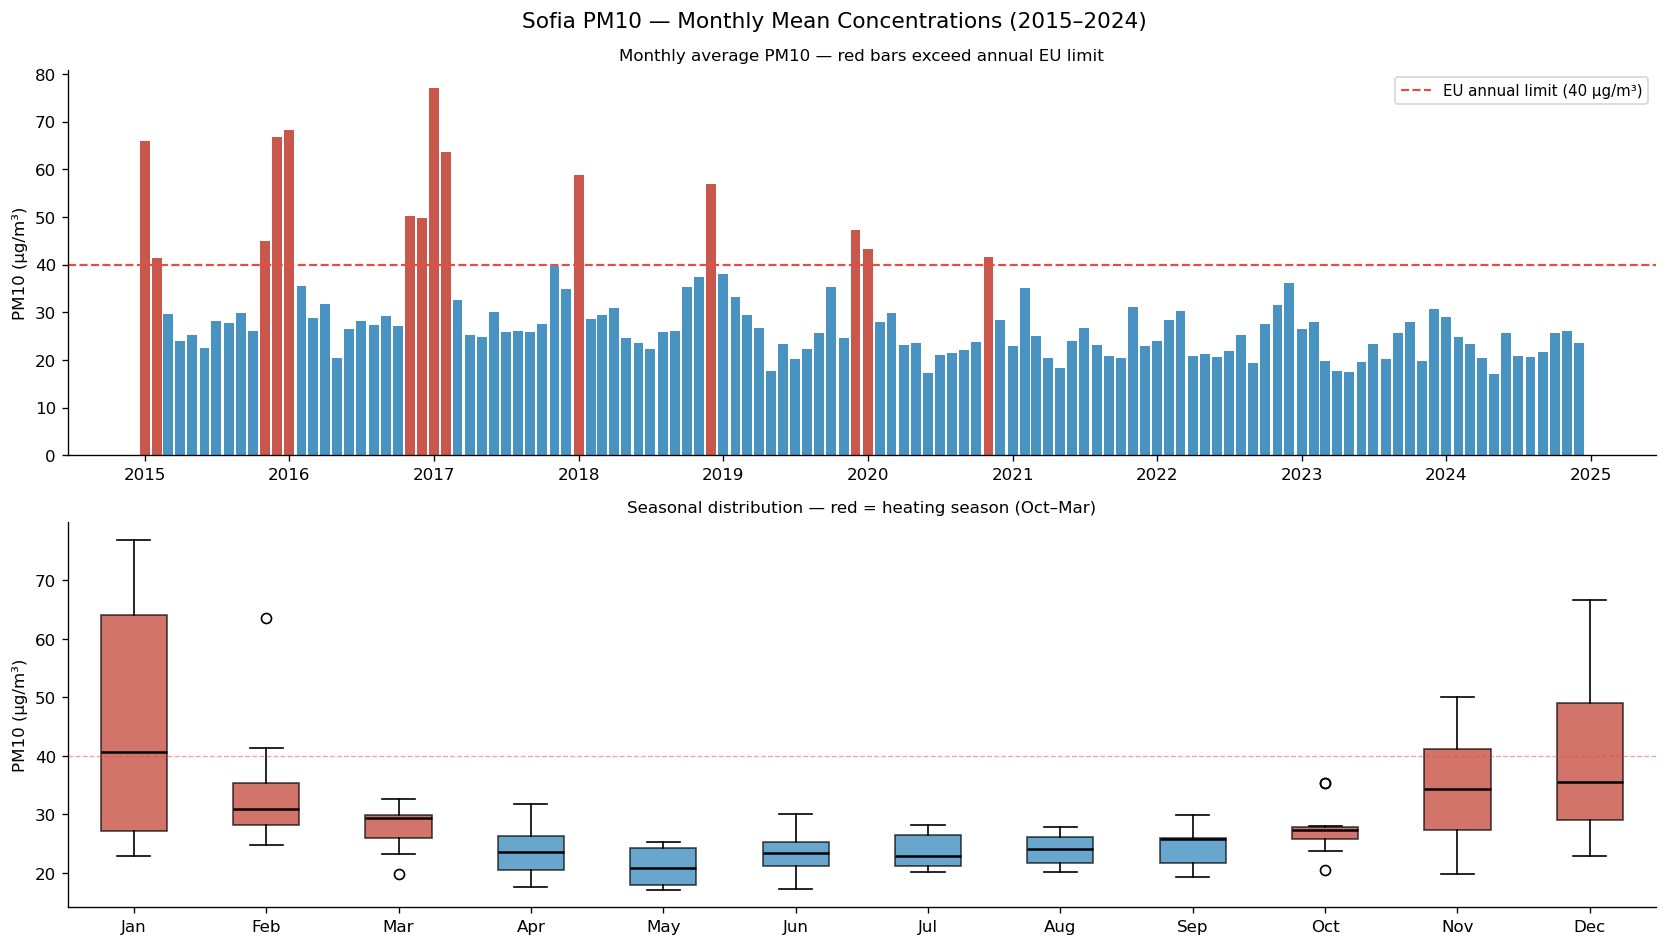

In [30]:
# EDA — PM10 time series and seasonal decomposition

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Sofia PM10 — Monthly Mean Concentrations (2015–2024)', fontsize=13)

# Top: time series with EU limit line
ax = axes[0]
colors = ['#c0392b' if v > 40 else '#2980b9' for v in df['pm10_mean']]
ax.bar(df['date'], df['pm10_mean'], color=colors, width=25, alpha=0.85)
ax.axhline(40, color='#e74c3c', ls='--', lw=1.3, label='EU annual-limit reference (40 µg/m³)')
ax.set_ylabel('PM10 (µg/m³)')
ax.legend(fontsize=9)
ax.set_title('Monthly average PM10 — red bars exceed annual EU limit', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Bottom: boxplot by month-of-year
ax2 = axes[1]
monthly_box = [df[df['month_num'] == m]['pm10_mean'].values for m in range(1, 13)]
bp = ax2.boxplot(monthly_box, patch_artist=True,
                 medianprops=dict(color='black', lw=1.5))
heating_months = [10, 11, 12, 1, 2, 3]
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#c0392b' if (i+1) in heating_months else '#2980b9')
    patch.set_alpha(0.7)
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax2.set_ylabel('PM10 (µg/m³)')
ax2.set_title('Seasonal distribution — red = heating season (Oct–Mar)', fontsize=10)
ax2.axhline(40, color='#e74c3c', ls='--', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

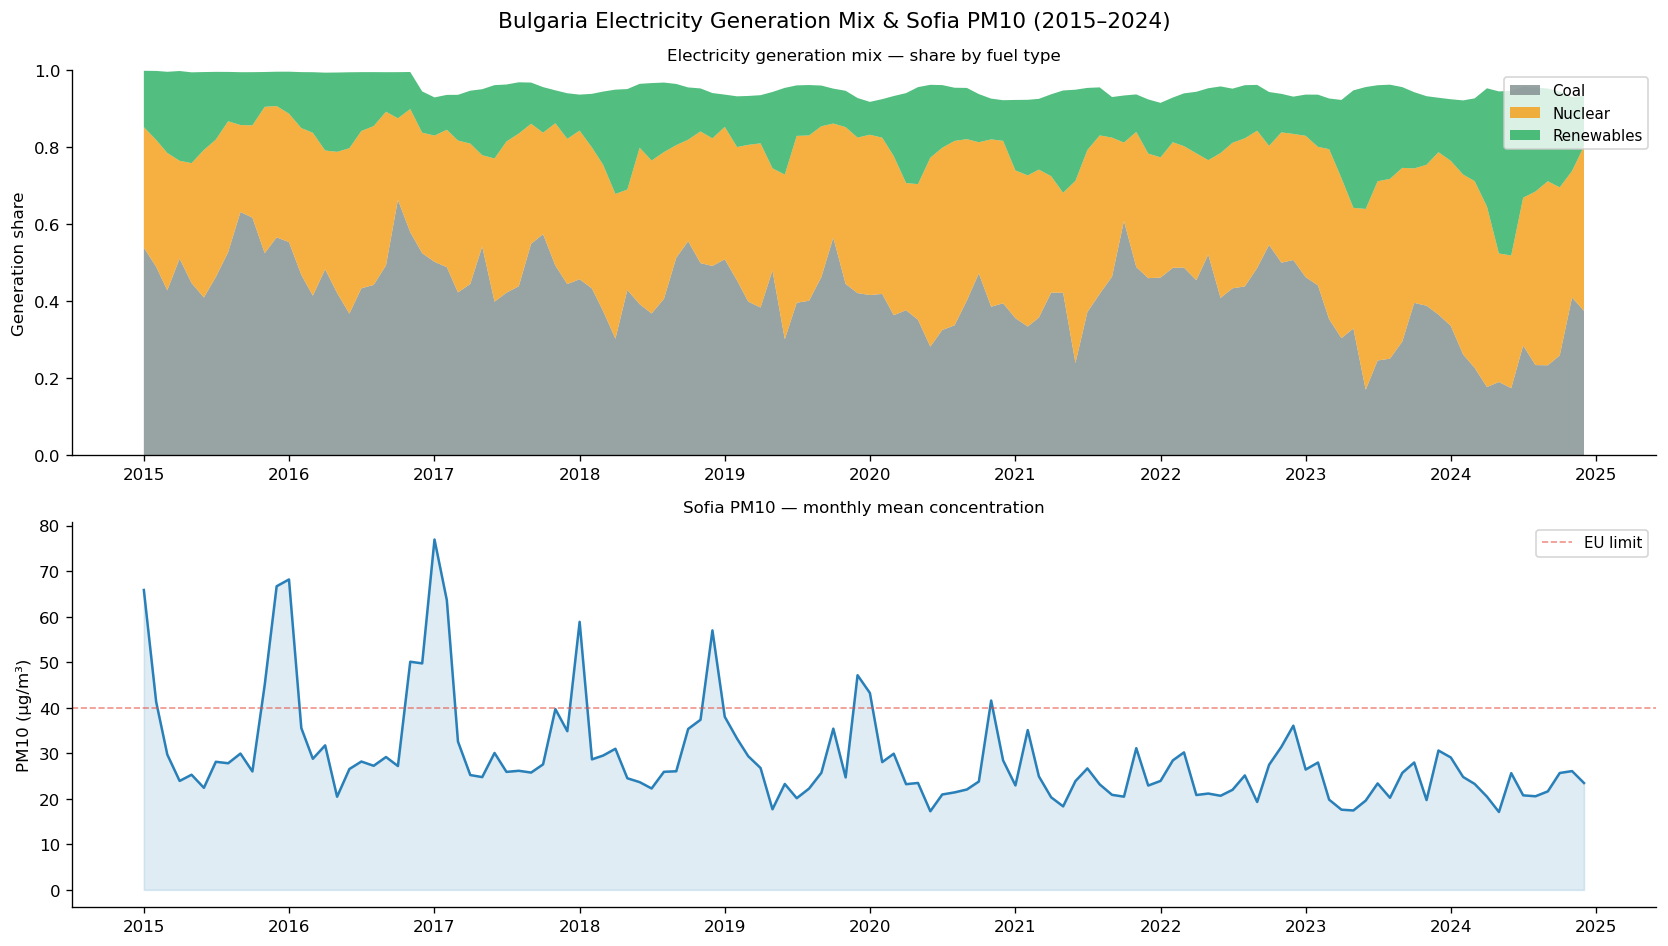

In [13]:
# EDA — Energy mix trend alongside PM10

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Bulgaria Electricity Generation Mix & Sofia PM10 (2015–2024)', fontsize=13)

ax1 = axes[0]
ax1.stackplot(
    df['date'],
    df['coal_share'],
    df['nuclear_share'],
    df['renewables_share'],
    labels=['Coal', 'Nuclear', 'Renewables'],
    colors=['#7f8c8d', '#f39c12', '#27ae60'],
    alpha=0.8
)
ax1.set_ylabel('Generation share')
ax1.set_ylim(0, 1)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_title('Electricity generation mix — share by fuel type', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2 = axes[1]
ax2.plot(df['date'], df['pm10_mean'], color='#2980b9', lw=1.5)
ax2.fill_between(df['date'], df['pm10_mean'], alpha=0.15, color='#2980b9')
ax2.axhline(40, color='#e74c3c', ls='--', lw=1.0, alpha=0.6, label='EU limit')
ax2.set_ylabel('PM10 (µg/m³)')
ax2.legend(fontsize=9)
ax2.set_title('Sofia PM10 — monthly mean concentration', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

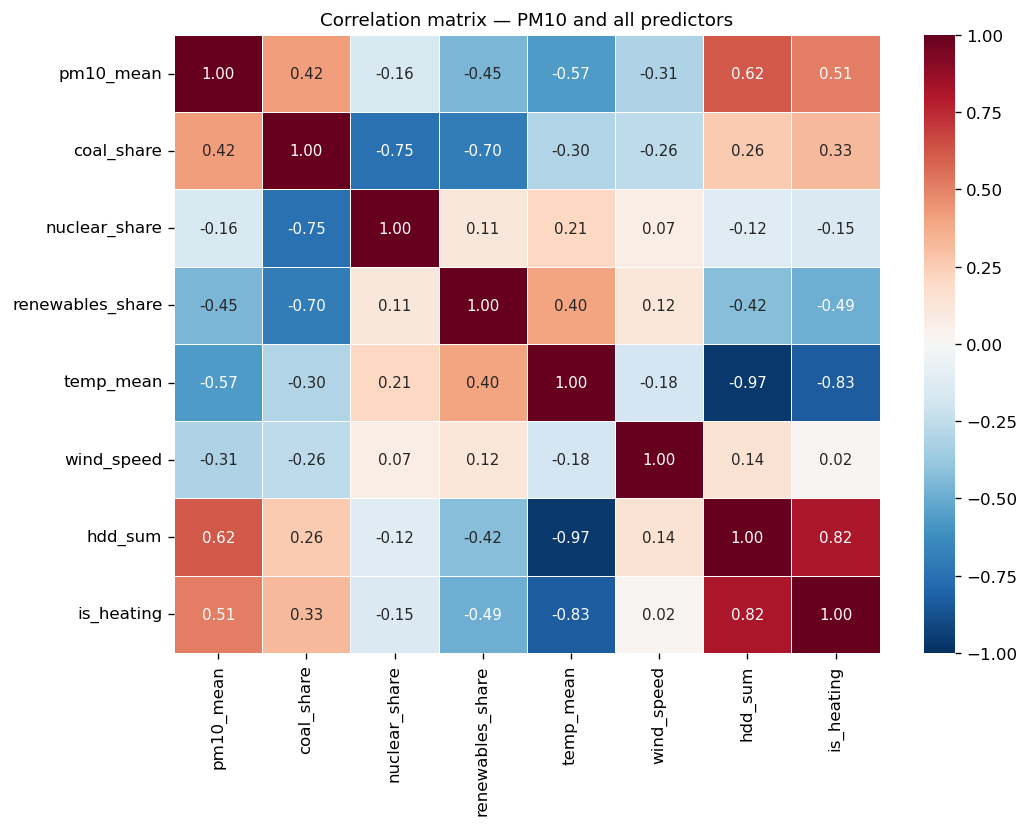


Correlations with PM10 (sorted by strength):
hdd_sum             0.624
temp_mean          -0.565
is_heating          0.512
renewables_share   -0.454
coal_share          0.416
wind_speed         -0.311
nuclear_share      -0.157
Name: pm10_mean, dtype: float64


In [14]:
# EDA — Correlation matrix

corr_cols = [
    'pm10_mean', 'coal_share', 'nuclear_share', 'renewables_share',
    'temp_mean', 'wind_speed', 'hdd_sum', 'is_heating'
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 9}
)
ax.set_title('Correlation matrix — PM10 and all predictors', fontsize=11)
plt.tight_layout()
plt.show()

print('\nCorrelations with PM10 (sorted by strength):')
print(corr['pm10_mean'].drop('pm10_mean').sort_values(key=abs, ascending=False).round(3))

---
## Section 5 — Regression Modelling

### 5.1 Model Specification

We fit four progressively richer models to isolate the effect of coal share:

- **Model A (baseline):** PM10 ~ coal_share only. Deliberately naive — the unconditional association.
- **Model B (weather controls):** PM10 ~ coal_share + temp_mean + wind_speed. Adds meteorological confounders.
- **Model C (full):** PM10 ~ coal_share + temp_mean + wind_speed + hdd_sum + is_heating + month dummies.
- **Model D (lagged / persistence-aware):** PM10 ~ coal_share + temp_mean + wind_speed + hdd_sum + C(month_num) + pm10_lag1. Adds a 1-month lag of PM10 to account for temporal persistence in pollution levels.

The key diagnostic is how $\hat{\beta}_{\text{coal}}$ and its p-value evolve from Model A through Model D. If the coefficient collapses or loses significance as controls are added, the raw correlation was driven by confounding. If the result remains stable even after accounting for persistence in Model D, this provides stronger evidence that the observed relationship is not purely driven by temporal dependence.

### 5.2 Time-Series Caveat

Although the model is written in standard regression form, the data are monthly and time-indexed.  
This means the independence of errors is not guaranteed: PM10 levels often persist from one month to the next, and residual autocorrelation can make ordinary OLS standard errors too optimistic.

To address this, we do three things:

1. **Diagnose residual autocorrelation** using the Durbin–Watson statistic and the Breusch–Godfrey test.  
2. **Estimate a persistence-aware model** by adding a 1-month lag of PM10 (`pm10_lag1`).  
3. **Report HAC / Newey–West robust standard errors** for the lagged model so inference is less sensitive to serial correlation.

These steps do not make the analysis causal, but they improve the reliability of statistical inference by addressing potential serial correlation in the error terms.

In [15]:
# TIME-SERIES PREP — sort data and create 1-month lag of PM10

df = df.sort_values('date').copy()
df['pm10_lag1'] = df['pm10_mean'].shift(1)

lag_df = df.dropna(subset=['pm10_lag1']).copy()

print('Rows in original monthly dataset:', len(df))
print('Rows after creating 1-month lag:', len(lag_df))
lag_df[['date', 'pm10_mean', 'pm10_lag1']].head()

Rows in original monthly dataset: 120
Rows after creating 1-month lag: 119


,date,pm10_mean,pm10_lag1
1,2015-02-01,41.285000,65.866720
2,2015-03-01,29.707258,41.285000
3,2015-04-01,23.923611,29.707258
4,2015-05-01,25.282785,23.923611
5,2015-06-01,22.411644,25.282785


In [16]:
# REGRESSION — Model A: naive baseline

model_a = smf.ols('pm10_mean ~ coal_share', data=df).fit()
print('=== Model A: Naive baseline ===')
print(model_a.summary2().tables[1].round(3))
print(f'R²: {model_a.rsquared:.3f}')

=== Model A: Naive baseline ===
             Coef.  Std.Err.      t  P>|t|  [0.025  0.975]
Intercept    9.532     4.072  2.341  0.021   1.467  17.596
coal_share  46.789     9.412  4.971  0.000  28.151  65.426
R²: 0.173


In [17]:
# REGRESSION — Model B: add meteorological controls

model_b = smf.ols(
    'pm10_mean ~ coal_share + temp_mean + wind_speed',
    data=df
).fit()
print('=== Model B: Weather controls ===')
print(model_b.summary2().tables[1].round(3))
print(f'R²: {model_b.rsquared:.3f}  |  Adj R²: {model_b.rsquared_adj:.3f}')

=== Model B: Weather controls ===
             Coef.  Std.Err.      t  P>|t|  [0.025  0.975]
Intercept   68.049     8.871  7.671  0.000  50.479  85.620
coal_share  15.600     8.123  1.920  0.057  -0.489  31.690
temp_mean   -0.851     0.102 -8.370  0.000  -1.052  -0.649
wind_speed  -2.719     0.500 -5.437  0.000  -3.710  -1.729
R²: 0.512  |  Adj R²: 0.499


In [18]:
# REGRESSION — Model C: full specification

model_c = smf.ols(
    'pm10_mean ~ coal_share + temp_mean + wind_speed + hdd_sum + is_heating + C(month_num)',
    data=df
).fit()
print('=== Model C: Full specification ===')
print(model_c.summary())

=== Model C: Full specification ===
                            OLS Regression Results                            
Dep. Variable:              pm10_mean   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     11.18
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.14e-15
Time:                        16:11:29   Log-Likelihood:                -402.92
No. Observations:                 120   AIC:                             837.8
Df Residuals:                     104   BIC:                             882.4
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------


In [20]:
# REGRESSION — Model D: lagged PM10 + HAC-robust inference

model_d = smf.ols(
    'pm10_mean ~ pm10_lag1 + coal_share + temp_mean + wind_speed + hdd_sum + C(month_num)',
    data=lag_df
).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

print('=== Model D: Lagged PM10 + HAC robust standard errors ===')
print(model_d.summary())

=== Model D: Lagged PM10 + HAC robust standard errors ===
                            OLS Regression Results                            
Dep. Variable:              pm10_mean   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     10.68
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.95e-15
Time:                        16:15:31   Log-Likelihood:                -388.92
No. Observations:                 119   AIC:                             811.8
Df Residuals:                     102   BIC:                             859.1
Df Model:                          16                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [21]:
# MULTICOLLINEARITY CHECK — Variance Inflation Factors

feature_cols = ['coal_share', 'temp_mean', 'wind_speed', 'hdd_sum', 'is_heating']
X_vif = sm.add_constant(df[feature_cols].dropna())

vif_df = pd.DataFrame({
    'Feature': feature_cols,
    'VIF':     [variance_inflation_factor(X_vif.values, i+1)
                for i in range(len(feature_cols))]
})
print('Variance Inflation Factors (VIF > 10 = problematic):')
print(vif_df.round(2).to_string(index=False))

Variance Inflation Factors (VIF > 10 = problematic):
   Feature   VIF
coal_share  1.29
 temp_mean 18.45
wind_speed  1.25
   hdd_sum 15.95
is_heating  3.49


In [22]:
# COEFFICIENT EVOLUTION TABLE — key diagnostic

models = {
    'A: Naive':     model_a,
    'B: + Weather': model_b,
    'C: Full':      model_c,
}

rows = []
for name, m in models.items():
    rows.append({
        'Model':       name,
        'β_coal':      m.params.get('coal_share', np.nan),
        'p-value':     m.pvalues.get('coal_share', np.nan),
        'R²':          m.rsquared,
        'Adj R²':      m.rsquared_adj,
    })

coef_table = pd.DataFrame(rows)
coef_table['Significant (p<0.05)'] = coef_table['p-value'] < 0.05
print('How the coal share coefficient changes as confounders are added:')
print(coef_table.round(4).to_string(index=False))

How the coal share coefficient changes as confounders are added:
       Model  β_coal  p-value     R²  Adj R²  Significant (p<0.05)
    A: Naive 46.7887   0.0000 0.1732  0.1662                  True
B: + Weather 15.6005   0.0573 0.5115  0.4989                 False
     C: Full 24.1536   0.0080 0.6173  0.5621                  True


In [23]:
# COEFFICIENT EVOLUTION TABLE — including lagged model

models_extended = {
    'A: Naive':               model_a,
    'B: + Weather':           model_b,
    'C: Full':                model_c,
    'D: + PM10 lag (HAC SE)': model_d,
}

rows = []
for name, m in models_extended.items():
    rows.append({
        'Model':       name,
        'β_coal':      m.params.get('coal_share', np.nan),
        'p-value':     m.pvalues.get('coal_share', np.nan),
        'β_pm10_lag1': m.params.get('pm10_lag1', np.nan),
        'R²':          m.rsquared,
        'Adj R²':      m.rsquared_adj,
    })

coef_table_extended = pd.DataFrame(rows)
coef_table_extended['Significant (p<0.05)'] = coef_table_extended['p-value'] < 0.05

print('How the coal-share coefficient changes after adding persistence:')
print(coef_table_extended.round(4).to_string(index=False))

How the coal-share coefficient changes after adding persistence:
                 Model  β_coal  p-value  β_pm10_lag1     R²  Adj R²  Significant (p<0.05)
              A: Naive 46.7887   0.0000          NaN 0.1732  0.1662                  True
          B: + Weather 15.6005   0.0573          NaN 0.5115  0.4989                 False
               C: Full 24.1536   0.0080          NaN 0.6173  0.5621                  True
D: + PM10 lag (HAC SE) 11.9682   0.0722       0.3429 0.6515  0.5968                 False


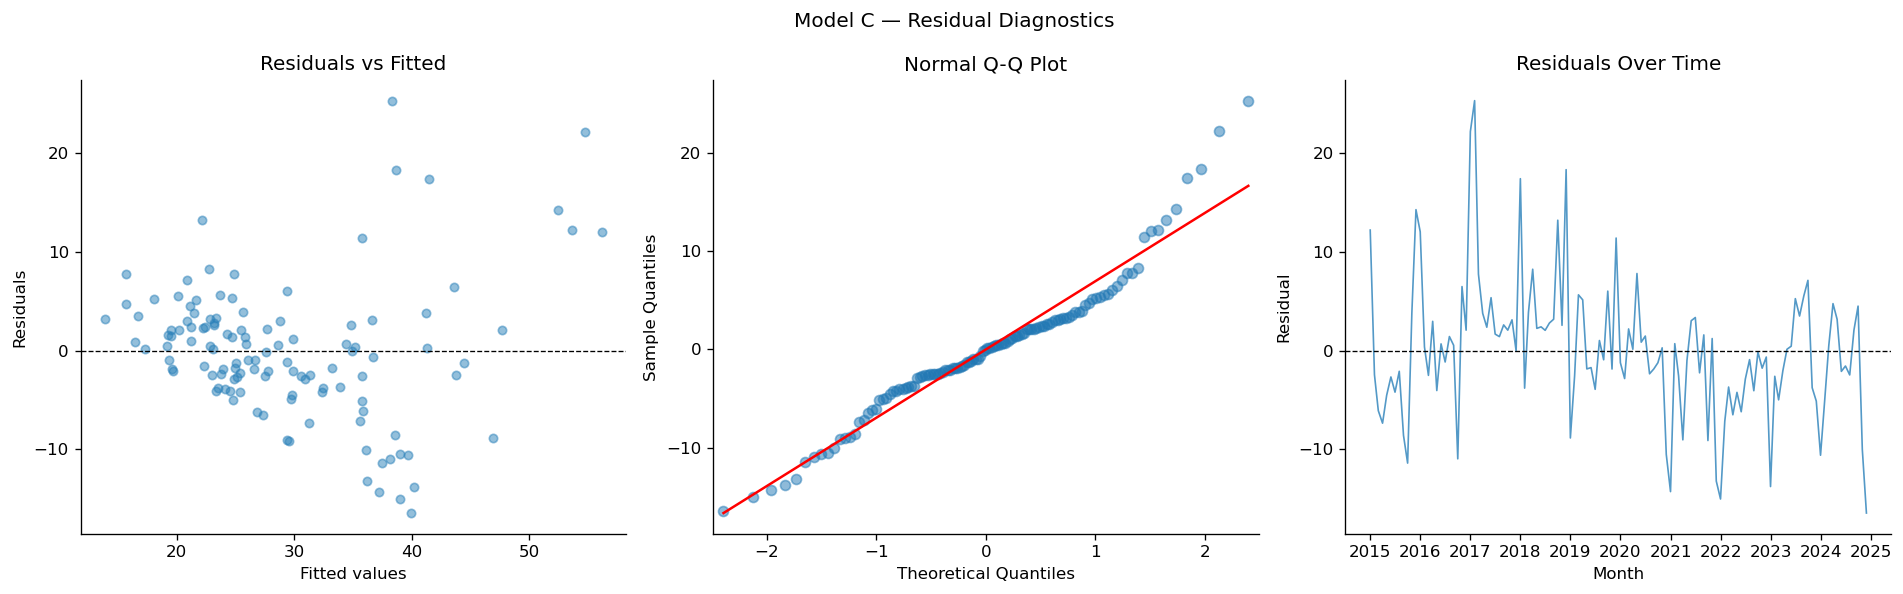

In [24]:
# RESIDUAL DIAGNOSTICS — Model C

residuals = model_c.resid
fitted    = model_c.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model C — Residual Diagnostics', fontsize=12)

axes[0].scatter(fitted, residuals, alpha=0.5, s=25, color='#2980b9')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q Plot')

axes[2].plot(df['date'], residuals, color='#2980b9', lw=1.0, alpha=0.8)
axes[2].axhline(0, color='black', lw=0.8, ls='--')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals Over Time')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [25]:
# TIME-SERIES DIAGNOSTICS — autocorrelation checks

dw_c = durbin_watson(model_c.resid)
bg_lm, bg_lm_pvalue, bg_f, bg_f_pvalue = acorr_breusch_godfrey(model_c, nlags=1)

print('Model C autocorrelation diagnostics')
print(f'  Durbin-Watson: {dw_c:.3f}')
print(f'  Breusch-Godfrey LM p-value (lag 1): {bg_lm_pvalue:.4f}')
print(f'  Breusch-Godfrey F-test p-value (lag 1): {bg_f_pvalue:.4f}')

dw_d = durbin_watson(model_d.resid)
print('\nModel D autocorrelation diagnostic')
print(f'  Durbin-Watson: {dw_d:.3f}')

Model C autocorrelation diagnostics
  Durbin-Watson: 1.208
  Breusch-Godfrey LM p-value (lag 1): 0.0000
  Breusch-Godfrey F-test p-value (lag 1): 0.0001

Model D autocorrelation diagnostic
  Durbin-Watson: 1.934


**How to read these diagnostics**

- A **Durbin–Watson** value near **2** suggests little first-order autocorrelation.  
- Values **well below 2** suggest positive autocorrelation.  
- A **small Breusch–Godfrey p-value** suggests residual autocorrelation is still present.

If Model D improves these diagnostics relative to Model C, this suggests that adding a lagged PM10 term helps capture temporal persistence that plain OLS may have missed.

---
## Section 6 — Random Forest Benchmark

### 6.1 Purpose

The multiple linear regression assumes linearity and additive effects. Random Forest is used as a flexible, non-linear benchmark to assess whether variable importance patterns are consistent with linear model findings. If both methods produce similar importance rankings, this provides additional support that the linear model is capturing meaningful relationships in the data, although it does not constitute causal or definitive validation. We use permutation importance computed on the held-out test set, which is more reliable than impurity-based importance, as the latter is biased towards high-cardinality features.

In [26]:
# RANDOM FOREST — Training and evaluation

FEATURES = [
    'coal_share', 'nuclear_share', 'renewables_share',
    'temp_mean', 'wind_speed', 'hdd_sum', 'is_heating', 'month_num'
]
TARGET = 'pm10_mean'

model_df = df[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES].values
y = model_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Random Forest — Test set performance:')
print(f'  R²:   {r2_score(y_test, y_pred):.3f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred):.2f} µg/m³')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} µg/m³')

Random Forest — Test set performance:
  R²:   0.516
  MAE:  6.69 µg/m³
  RMSE: 9.91 µg/m³


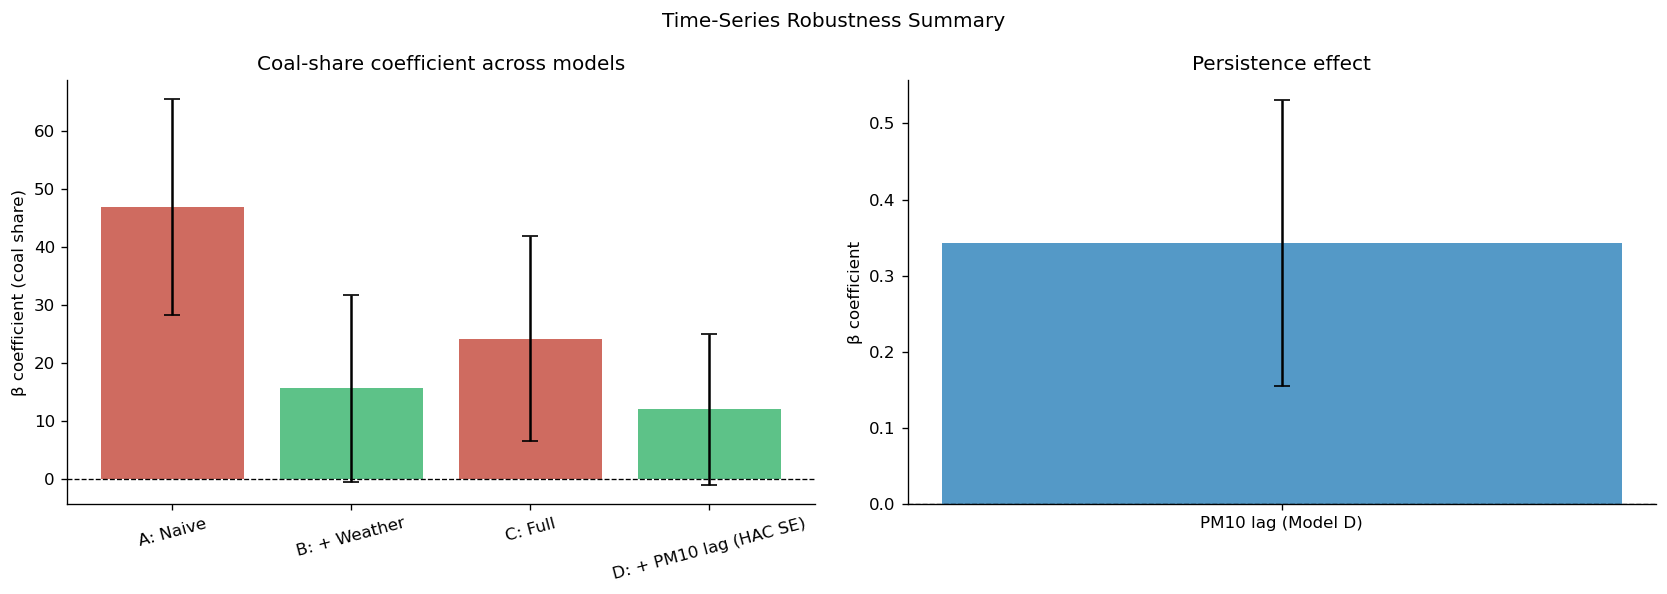

In [27]:
# RESULTS SUMMARY PLOT — add lagged model comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Time-Series Robustness Summary', fontsize=12)

# Left: coal coefficient across models including lagged model
ax = axes[0]
model_names = list(models_extended.keys())
betas = [m.params.get('coal_share', np.nan) for m in models_extended.values()]
cis = [
    m.conf_int().loc['coal_share'].values
    if 'coal_share' in m.params.index else [np.nan, np.nan]
    for m in models_extended.values()
]
yerr_low  = [b - ci[0] for b, ci in zip(betas, cis)]
yerr_high = [ci[1] - b for b, ci in zip(betas, cis)]
bar_colors = [
    '#c0392b' if m.pvalues.get('coal_share', 1) < 0.05 else '#27ae60'
    for m in models_extended.values()
]
ax.bar(model_names, betas, yerr=[yerr_low, yerr_high], color=bar_colors, alpha=0.75, capsize=5)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('β coefficient (coal share)')
ax.set_title('Coal-share coefficient across models')
ax.tick_params(axis='x', rotation=15)

# Right: lagged PM10 coefficient only
ax2 = axes[1]
lag_beta = model_d.params.get('pm10_lag1', np.nan)
lag_ci = model_d.conf_int().loc['pm10_lag1'].values
ax2.bar(['PM10 lag (Model D)'], [lag_beta],
        yerr=[[lag_beta - lag_ci[0]], [lag_ci[1] - lag_beta]],
        color='#2980b9', alpha=0.8, capsize=5)
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_ylabel('β coefficient')
ax2.set_title('Persistence effect')

plt.tight_layout()
plt.show()

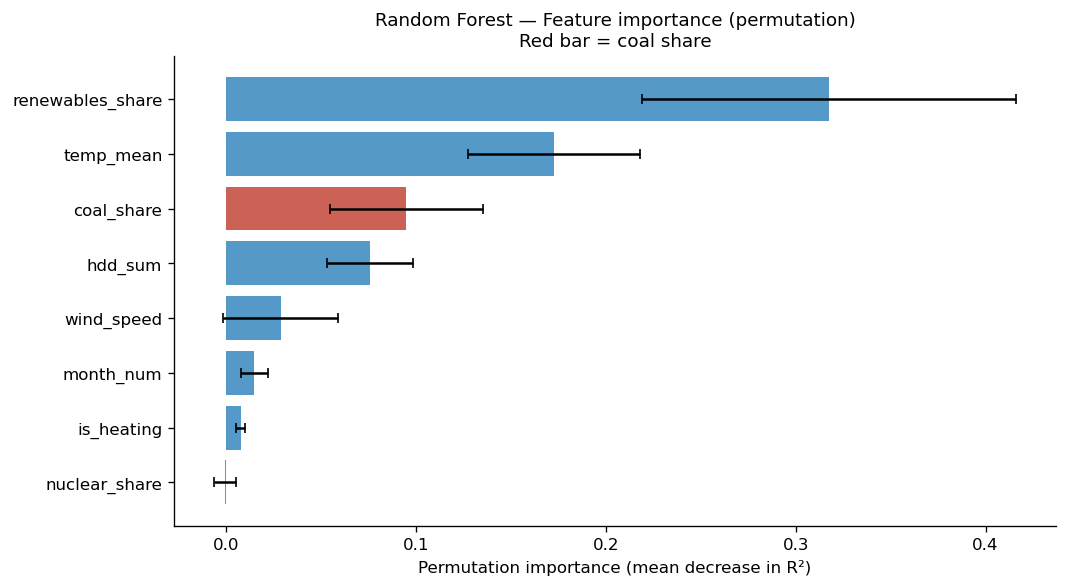


Feature importances (ranked):
         Feature  Importance
renewables_share      0.3175
       temp_mean      0.1727
      coal_share      0.0950
         hdd_sum      0.0758
      wind_speed      0.0290
       month_num      0.0151
      is_heating      0.0078
   nuclear_share     -0.0003


In [28]:
# RANDOM FOREST — Permutation feature importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

imp_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if f == 'coal_share' else '#2980b9' for f in imp_df['Feature']]
ax.barh(
    imp_df['Feature'], imp_df['Importance'],
    xerr=imp_df['Std'], color=colors, alpha=0.8, capsize=3
)
ax.set_xlabel('Permutation importance (mean decrease in R²)')
ax.set_title(
    'Random Forest — Feature importance (permutation)\nRed bar = coal share', fontsize=11
)
plt.tight_layout()
plt.show()

print('\nFeature importances (ranked):')
print(imp_df[['Feature','Importance']].sort_values('Importance', ascending=False).round(4).to_string(index=False))

---
## Section 7 — Results & Interpretation

### 7.1 Reading the Results

The central result is the behaviour of $\hat{\beta}_{\text{coal}}$ across the three models. Two outcomes are possible, and both are legitimate findings:

**If $\hat{\beta}_{\text{coal}}$ remains significant in Model C:** the electricity generation mix exerts a detectable partial effect on Sofia's PM10 after controlling for heating and weather. The coefficient magnitude tells us the PM10 change per unit increase in coal share.

**If $\hat{\beta}_{\text{coal}}$ becomes insignificant in Model C:** the raw correlation was driven by confounding — the grid signal is undetectable once seasonal and meteorological variation is removed. This is a substantive finding, not a failure.

### 7.2 Comparing MLR and Random Forest

Random Forest permutation importance serves as a non-linear benchmark for comparing variable importance patterns.

### 7.3 Time-Series Robustness Check

Model D adds a 1-month lag of PM10 and reports HAC-robust standard errors. If the coal-share coefficient remains small or insignificant after this step, the conclusion is more credible because it is no longer relying only on i.i.d.-style OLS inference.


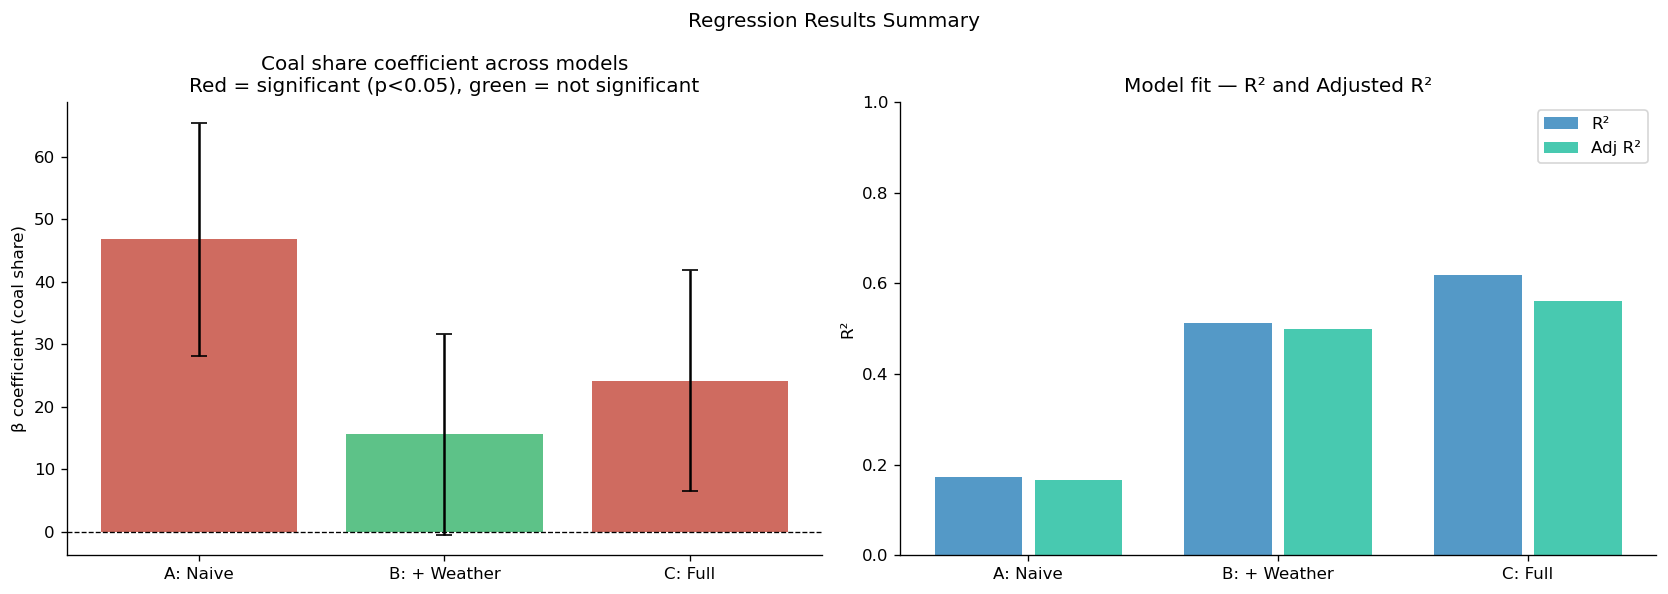

In [29]:
# RESULTS SUMMARY PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression Results Summary', fontsize=12)

# Left: coal coefficient across models with 95% CI
ax = axes[0]
model_names = list(models.keys())
betas  = [m.params.get('coal_share', np.nan) for m in models.values()]
cis    = [
    m.conf_int().loc['coal_share'].values
    if 'coal_share' in m.params else [np.nan, np.nan]
    for m in models.values()
]
yerr_low  = [b - ci[0] for b, ci in zip(betas, cis)]
yerr_high = [ci[1] - b for b, ci in zip(betas, cis)]
bar_colors = [
    '#c0392b' if m.pvalues.get('coal_share', 1) < 0.05 else '#27ae60'
    for m in models.values()
]
ax.bar(model_names, betas, yerr=[yerr_low, yerr_high],
       color=bar_colors, alpha=0.75, capsize=5)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('β coefficient (coal share)')
ax.set_title('Coal share coefficient across models\nRed = significant (p<0.05), green = not significant')

# Right: R² comparison
ax2 = axes[1]
r2s     = [m.rsquared     for m in models.values()]
r2s_adj = [m.rsquared_adj for m in models.values()]
x_pos   = np.arange(len(model_names))
ax2.bar(x_pos - 0.2, r2s,     0.35, label='R²',     color='#2980b9', alpha=0.8)
ax2.bar(x_pos + 0.2, r2s_adj, 0.35, label='Adj R²', color='#1abc9c', alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(model_names)
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_title('Model fit — R² and Adjusted R²')

plt.tight_layout()
plt.show()

---
## Section 8 — Conclusion & Reflection

### 8.1 What the Model Shows

This project set out to answer a single, tightly scoped question: does Bulgaria's decarbonizing electricity grid leave a detectable fingerprint on Sofia's air quality, once we strip away the dominant influence of heating season and weather?

The progression from Model A to Model D shows that the apparent coal-share effect weakens after accounting for weather, seasonality, and temporal persistence. Model C suggests a significant association, but Model D reduces the coefficient and makes it statistically insignificant at the 5% level, so the evidence for a robust coal-share effect is limited.

### 8.2 Model Limitations

| Limitation | Impact |
|---|---|
| Domestic heating not directly measured | The largest PM10 source in Sofia is proxied only through HDD and a binary season variable |
| Coal not split into lignite vs. hard coal | Ember does not disaggregate at monthly national level — the coal variable combines both |
| Monthly aggregation | Daily variation in grid mix — which may matter for short-term pollution spikes — is lost |
| No traffic data | Road transport is a known PM10 contributor in Sofia and remains uncontrolled |
| Observational study | Regression identifies association, not causation |

### 8.3 Policy Implication

Whatever the coal coefficient result, the EDA makes one thing clear: investment in heating system transitions — heat pumps, district heating, stove replacement — will produce larger air quality gains than grid decarbonization alone at the urban monthly timescale studied here, where pollution dynamics are driven primarily by seasonal heating demand and meteorological conditions.

---

### References

**Data sources**
1. EEA Air Quality e-Reporting Database (Verified E1a). https://eeadmz1-downloads-webapp.azurewebsites.net/
2. Ember Monthly Electricity Data (CC BY 4.0). https://ember-energy.org/data/monthly-electricity-data/
3. Open-Meteo Historical Weather API. https://open-meteo.com/en/docs/historical-weather-api
4. Hersbach, H. et al. (2023). ERA5 hourly data on single levels from 1940 to present. ECMWF. https://doi.org/10.24381/cds.adbb2d47

**Section 1**
5. Dimitriou, K. et al. (2021). Assessment of the Contribution of Different Particulate Matter Sources on Pollution in Sofia City. *Atmosphere*, 12(4), 423. https://doi.org/10.3390/atmos12040423
6. EEA (2025). Air Quality Status Report 2025. https://www.eea.europa.eu/en/analysis/publications/air-quality-status-report-2025
7. World Scientific (2023). What are the main sources of air pollution in Sofia, Bulgaria? *Molecular Frontiers Journal*. https://www.worldscientific.com/doi/10.1142/S2529732523970076

**Section 2**
8. James, G. et al. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. https://www.statlearning.com
9. Greene, W.H. (2018). *Econometric Analysis*, 8th ed. Pearson.

**Section 5**
10. Sofiapm10.report — PM10 prediction in Sofia using citizen sensor networks. https://sofiapm10.report/summary.html

**Section 6**
11. Breiman, L. (2001). Random Forests. *Machine Learning*, 45, 5–32. https://doi.org/10.1023/A:1010933404324
12. Strobl, C. et al. (2007). Bias in random forest variable importance measures. *BMC Bioinformatics*, 8, 25.

**General**
13. Enerdata (2024). Bulgaria Energy Profile. https://www.enerdata.net/estore/energy-market/bulgaria/
14. European Parliament (2024). Bulgaria's Climate Action Strategy. https://www.europarl.europa.eu/RegData/etudes/BRIE/2024/767172/EPRS_BRI(2024)767172_EN.pdf